In [2]:
import cartopy.crs as ccrs
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pypsa
from pypsa.costs import annuity

RESOLUTION = 3  # 3-hourly

In [3]:
n = pypsa.Network()

REGIONS = pd.Index(["VIC", "SA", "NSW"])
LAT = [-37.81, -34.93, -33.87]
LON = [145.01, 138.63, 151.20]
n.add("Bus", REGIONS, x=LON, y=LAT);

In [4]:
CARRIERS = {
    "solar": "gold",
    "wind": "steelblue",
    "load shedding": "indianred",
    "battery charger": "lightgreen",
    "battery discharger": "lightgreen",
    "battery storage": "grey",
    "battery": "grey",
    "electrolysis": "violet",
    "turbine": "violet",
    "hydrogen storage": "orchid",
    "hydrogen": "orchid",
    "AC": "black",
    "HVDC": "lightseagreen",
    "load": "slategrey",
}

n.add(
    "Carrier",
    CARRIERS.keys(),
    color=CARRIERS.values(),
);

In [5]:
url = "https://tubcloud.tu-berlin.de/s/oPQbAebrciFBZP2/download/australia-example-p_max_pu.csv"
p_max_pu = pd.read_csv(url, index_col=0, parse_dates=True, header=[0, 1])
display(p_max_pu.head(3))

url = "https://tubcloud.tu-berlin.de/s/8C6d7z3HxE7yZi9/download/australia-example-p_set.csv"
p_set = pd.read_csv(url, index_col=0, parse_dates=True)
display(p_set.head(3))

n.set_snapshots(p_max_pu.index)

VIC            SA           NSW       
                    onwind  solar onwind  solar onwind  solar
2011-01-01 00:00:00  0.214  0.504  0.239  0.401  0.141  0.515
2011-01-01 01:00:00  0.197  0.588  0.244  0.504  0.098  0.597
2011-01-01 02:00:00  0.215  0.613  0.232  0.568  0.068  0.644

,VIC,SA,NSW
snapshot,,,
2011-01-01 00:00:00,5113.930,1358.385,9357.435
2011-01-01 01:00:00,5147.425,1383.295,9635.540
2011-01-01 02:00:00,5079.465,1387.215,9832.175


In [6]:
n.add("Load", REGIONS, suffix=" load", bus=REGIONS, p_set=p_set, carrier="load");

In [7]:
p_max_pu_wind = p_max_pu.xs("onwind", level=1, axis=1).rename(
    columns=lambda s: s + " wind"
)

n.add(
    "Generator",
    p_max_pu_wind.columns,
    bus=REGIONS,
    p_max_pu=p_max_pu_wind,
    p_nom_extendable=True,
    capital_cost=annuity(0.05, 30) * 2_000_000,
    marginal_cost=0.5,
    carrier="wind",
)

p_max_pu_solar = p_max_pu.xs("solar", level=1, axis=1).rename(
    columns=lambda s: s + " solar"
)

n.add(
    "Generator",
    p_max_pu_solar.columns,
    bus=REGIONS,
    p_max_pu=p_max_pu_solar,
    p_nom_extendable=True,
    capital_cost=annuity(0.05, 30) * 700_000,
    carrier="solar",
);

In [8]:
n.add(
    "Generator",
    REGIONS,
    suffix=" load shedding",
    bus=REGIONS,
    p_nom=p_set.max(),
    marginal_cost=3000,
    carrier="load shedding",
);

In [14]:
n.set_snapshots(n.snapshots[::RESOLUTION])
n.snapshot_weightings.loc[:, :] = RESOLUTION

n.optimize(solver_name="gurobi")

/var/folders/t_/32_5y8z906v9c0l8qphz6hx00000gn/T/ipykernel_49055/3103030024.py:4: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

INFO:linopy.model: Solve problem using Gurobi solver


AssertionError: Solver gurobi not installed

In [15]:
display(n.statistics.energy_balance().div(1e6).round(2).sort_values())  # TWh

average_cost = (
    (n.statistics.capex().sum() + n.statistics.opex().sum())
    / n.loads_t.p_set.sum().sum()
    / RESOLUTION
)

display(f"Average cost: {average_cost:.2f} AUD/MWh")

component  carrier        bus_carrier
Load       load           AC            -15.52
Generator  load shedding  AC              0.85
           solar          AC              5.64
           wind           AC              9.04
dtype: float64

'Average cost: 1088.58 AUD/MWh'

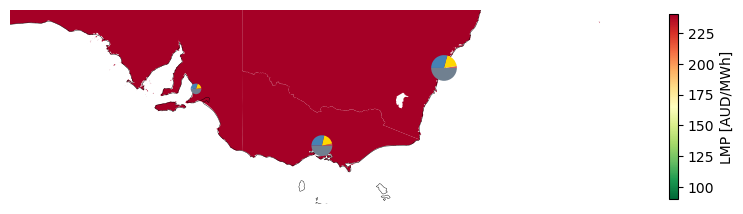

In [16]:
# Create an empty figure with a Cartopy projection
crs = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": crs})

# Use the energy balance statistics to prepare the bus sizes and plot the network
bus_size = n.statistics.energy_balance(groupby=["bus", "carrier"]).droplevel(
    "component"
)
n.plot(ax=ax, bus_size=bus_size / 4e7, margin=0.75, bus_split_circle=True)

# Load the shapefiles and add them to the plot colored by average LMP
prices = n.buses_t.marginal_price.mean()
gdf = gpd.read_file(
    "https://tubcloud.tu-berlin.de/s/4n9PegitETESBGR/download/australia-example-shapes.geojson"
).set_index("index")
gdf.to_crs(crs).plot(ax=ax, column=prices, cmap="RdYlGn_r", vmin=90, vmax=240)

# Add a legend for the LMP color scale
norm = plt.Normalize(vmin=90, vmax=240)
sm = plt.cm.ScalarMappable(cmap="RdYlGn_r", norm=norm)
fig.colorbar(sm, ax=ax, label="LMP [AUD/MWh]", shrink=0.4)

In [13]:
n.add("Bus", REGIONS, suffix=" hydrogen", carrier="hydrogen", x=LON, y=LAT)

n.add(
    "Link",
    REGIONS,
    suffix=" electrolysis",
    bus0=REGIONS,
    bus1=pd.Index(REGIONS) + " hydrogen",
    carrier="electrolysis",
    p_nom_extendable=True,
    efficiency=0.7,
    capital_cost=annuity(0.05, 25) * 2_500_000,
)

n.add(
    "Link",
    REGIONS,
    suffix=" turbine",
    bus0=pd.Index(REGIONS) + " hydrogen",
    bus1=REGIONS,
    carrier="turbine",
    p_nom_extendable=True,
    efficiency=0.4,
    capital_cost=annuity(0.05, 25) * 2_000_000,
)

n.add(
    "Store",
    REGIONS,
    suffix=" hydrogen storage",
    bus=pd.Index(REGIONS) + " hydrogen",
    carrier="hydrogen storage",
    capital_cost=annuity(0.05, 30) * 80,
    e_nom_extendable=True,
    e_cyclic=True,
)

n.add("Bus", REGIONS, suffix=" battery", carrier="battery", x=LON, y=LAT)

n.add(
    "Link",
    REGIONS,
    suffix=" battery charger",
    bus0=REGIONS,
    bus1=REGIONS + " battery",
    carrier="battery charger",
    p_nom_extendable=True,
    efficiency=0.95,
    capital_cost=annuity(0.05, 10) * 300_000,
)

n.add(
    "Link",
    REGIONS,
    suffix=" battery discharger",
    bus0=REGIONS + " battery",
    bus1=REGIONS,
    carrier="battery discharger",
    p_nom_extendable=True,
    efficiency=0.95,
)

n.add(
    "Store",
    REGIONS,
    suffix=" battery storage",
    bus=REGIONS + " battery",
    carrier="battery storage",
    capital_cost=annuity(0.05, 25) * 250_000,
    e_nom_extendable=True,
    e_cyclic=True,
);

In [18]:
def battery_constraint(n: pypsa.Network, sns: pd.Index) -> None:
    """Constraint to ensure that the nominal capacity of battery chargers and dischargers are in a fixed ratio."""
    dischargers_i = n.links[n.links.index.str.contains(" discharger")].index
    chargers_i = n.links[n.links.index.str.contains(" charger")].index

    eff = n.links.efficiency[dischargers_i].values
    lhs = n.model["Link-p_nom"].loc[chargers_i]
    rhs = n.model["Link-p_nom"].loc[dischargers_i] * eff

    n.model.add_constraints(lhs == rhs, name="Link-charger_ratio")


n.optimize(extra_functionality=battery_constraint)

/var/folders/t_/32_5y8z906v9c0l8qphz6hx00000gn/T/ipykernel_49055/2285950923.py:13: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|████████████| 7/7 [00:00<00:00, 1054.91it/s]
INFO:linopy.io: Writing time: 0.07s


Running HiGHS 1.13.1 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-cnxxm2g9 has 22452 rows; 10749 cols; 43425 nonzeros
Coefficient ranges:
  Matrix  [1e-03, 3e+00]
  Cost    [2e+00, 2e+05]
  Bound   [0e+00, 0e+00]
  RHS     [1e+03, 1e+04]
Presolving model
12195 rows, 10266 cols, 32685 nonzeros  0s
10245 rows, 8316 cols, 28785 nonzeros  0s
Dependent equations search running on 2925 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
10245 rows, 8316 cols, 28785 nonzeros  0s
Presolve reductions: rows 10245(-12207); columns 8316(-2433); nonzeros 28785(-14640) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 975(5.03356e+06) 0.0s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 10749 primals, 22452 duals
Objective: 1.11e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.


       7551     1.1095390915e+10 Pr: 0(0); Du: 0(2.78731e-11) 0.3s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-cnxxm2g9
Model status        : Optimal
Simplex   iterations: 7551
Objective value     :  1.1095390915e+10
P-D objective error :  9.4547524830e-16
HiGHS run time      :          0.35


('ok', 'optimal')

In [19]:
display(
    n.statistics.energy_balance(bus_carrier="AC").div(1e6).round(2).sort_values()
)  # TWh

average_cost = (
    (n.statistics.capex().sum() + n.statistics.opex().sum())
    / n.loads_t.p_set.sum().sum()
    / RESOLUTION
)

print(f"Average cost: {average_cost:.2f} AUD/MWh")

component  carrier             bus_carrier
Load       load                AC            -15.52
Link       battery charger     AC             -3.24
           electrolysis        AC             -0.72
           turbine             AC              0.20
Generator  load shedding       AC              0.30
Link       battery discharger  AC              2.93
Generator  solar               AC              7.90
           wind                AC              8.16
dtype: float64

Average cost: 714.72 AUD/MWh


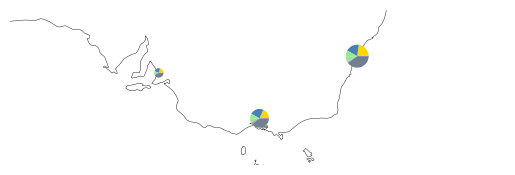

In [20]:
bus_size = (
    n.statistics.energy_balance(groupby=["bus", "carrier"])
    .droplevel("component")
    .loc[REGIONS]
)

n.plot(bus_size=bus_size / 4e7, margin=0.75, bus_split_circle=True);

<Axes: xlabel='Share of time [%]', ylabel='Price [AUD/MWh]'>

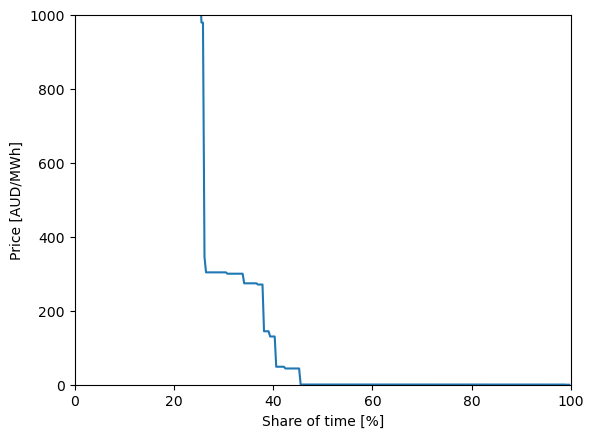

In [21]:
pdc = (
    n.buses_t.marginal_price["VIC"].sort_values(ascending=False).reset_index(drop=True)
)
pdc.index = np.arange(0, 100, 100 / len(pdc.index))
pdc.plot(
    ylim=[0, 1000], xlim=[0, 100], xlabel="Share of time [%]", ylabel="Price [AUD/MWh]"
)

In [22]:
connections = [
    ("VIC", "NSW", 700),  # km
    ("VIC", "SA", 650),  # km
    ("NSW", "SA", 1150),  # km
]

for bus0, bus1, length in connections:
    n.add(
        "Link",
        f"{bus0}-{bus1}",
        bus0=bus0,
        bus1=bus1,
        carrier="HVDC",
        p_nom_extendable=True,
        capital_cost=annuity(0.05, 40) * 1_000 * length,
        p_min_pu=-1,  # bidirectional
    )

In [23]:
n.optimize(extra_functionality=battery_constraint)

/var/folders/t_/32_5y8z906v9c0l8qphz6hx00000gn/T/ipykernel_49055/899683261.py:1: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|████████████| 7/7 [00:00<00:00, 1054.49it/s]
INFO:linopy.io: Writing time: 0.04s


Running HiGHS 1.13.1 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-sw30un86 has 24405 rows; 11727 cols; 49278 nonzeros
Coefficient ranges:
  Matrix  [1e-03, 3e+00]
  Cost    [2e+00, 2e+05]
  Bound   [0e+00, 0e+00]
  RHS     [1e+03, 1e+04]
Presolving model
14145 rows, 11244 cols, 38535 nonzeros  0s
12025 rows, 9124 cols, 36321 nonzeros  0s
Dependent equations search running on 2600 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
11870 rows, 8969 cols, 37579 nonzeros  0s
Presolve reductions: rows 11870(-12535); columns 8969(-2758); nonzeros 37579(-11699) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 975(6.49826e+06); Du: 0(3.08142e-10) 0.0s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 11727 primals, 24405 duals
Objective: 1.05e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.


      11951     1.0501331909e+10 Pr: 0(0); Du: 0(3.59325e-10) 1.5s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-sw30un86
Model status        : Optimal
Simplex   iterations: 11951
Objective value     :  1.0501331909e+10
P-D objective error :  1.8162921134e-16
HiGHS run time      :          1.46


('ok', 'optimal')

In [24]:
display(
    n.statistics.energy_balance(bus_carrier="AC").div(1e6).round(2).sort_values()
)  # TWh

average_cost = (
    (n.statistics.capex().sum() + n.statistics.opex().sum())
    / n.loads_t.p_set.sum().sum()
    / RESOLUTION
)

display(f"Average cost: {average_cost:.2f} AUD/MWh")

component  carrier             bus_carrier
Load       load                AC            -15.52
Link       battery charger     AC             -2.52
           electrolysis        AC             -0.56
           turbine             AC              0.16
Generator  load shedding       AC              0.31
Link       battery discharger  AC              2.28
Generator  solar               AC              6.50
           wind                AC              9.36
dtype: float64

'Average cost: 676.45 AUD/MWh'

{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x3601a3250>},
 'branches': {'Link': <matplotlib.collections.LineCollection at 0x3601a3390>},
 'flows': {'Link': <matplotlib.collections.PatchCollection at 0x3601a3750>}}

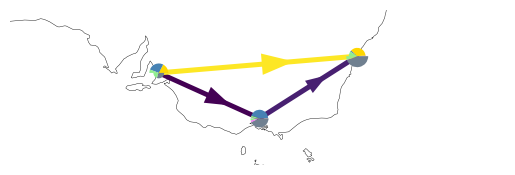

In [25]:
bus_size = (
    n.statistics.energy_balance(bus_carrier="AC", groupby=["bus", "carrier"])
    .droplevel("component")
    .loc[REGIONS]
    .drop("HVDC", level="carrier")
)

link_flow = n.links_t.p0.mean()[n.links.carrier == "HVDC"]

link_width = n.links.p_nom_opt[n.links.carrier == "HVDC"]

link_loading = n.links_t.p0.abs().mean()[n.links.carrier == "HVDC"] / link_width

n.plot(
    bus_size=bus_size / 4e7,
    margin=0.75,
    bus_split_circle=True,
    link_flow=link_flow / 50,
    link_width=link_width / 1e3,
    link_color=link_loading,
)

In [26]:
n.links.query("carrier == 'HVDC'").p_nom_opt.round(2)

name
VIC-NSW    3684.11
VIC-SA     3517.84
NSW-SA     3605.06
Name: p_nom_opt, dtype: float64

<Axes: xlabel='snapshot'>

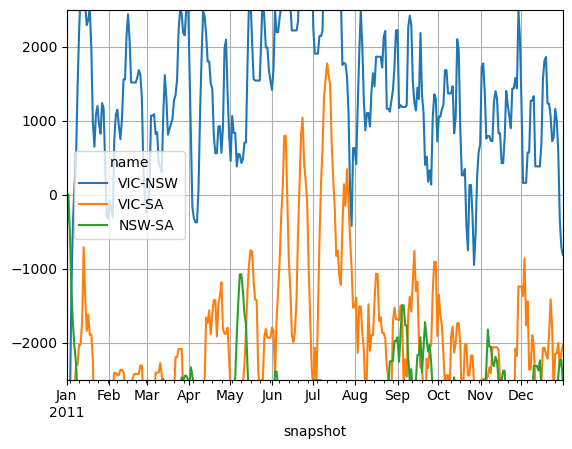

In [27]:
n.links_t.p0.loc[:, n.links.carrier == "HVDC"].rolling("7d").mean().plot(
    ylim=[-2500, 2500], grid=True
)

<Axes: xlabel='snapshot', ylabel='Hydrogen storage [TWh]'>

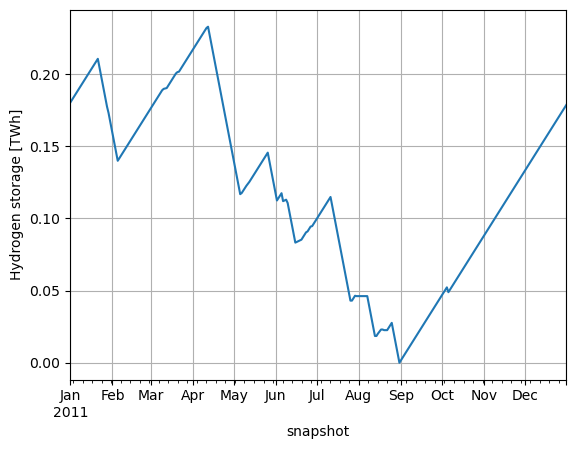

In [28]:
n.stores_t.e.filter(like="hydrogen").sum(axis=1).div(1e6).plot(
    ylabel="Hydrogen storage [TWh]", grid=True
)

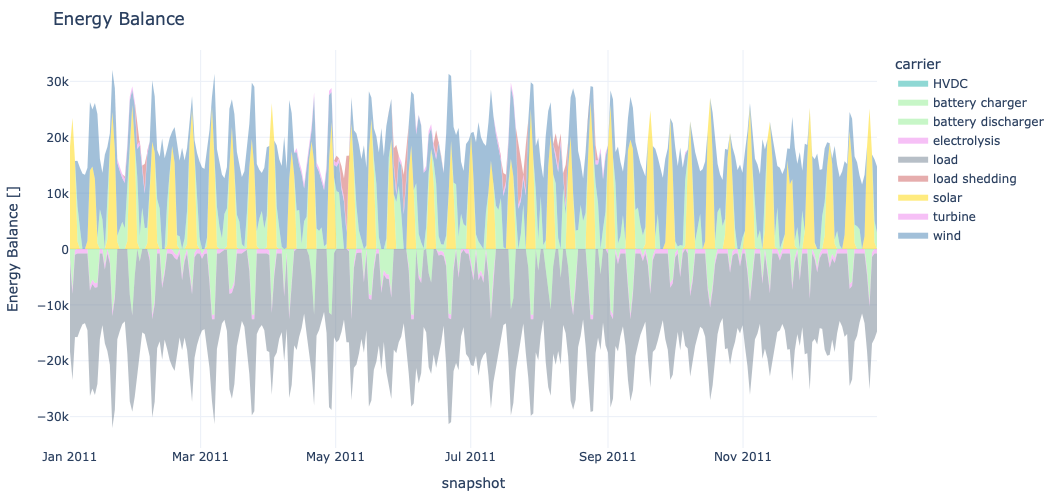

In [29]:
n.statistics.energy_balance.iplot.area(bus_carrier="AC")